In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from preprocessing.preprocessing_utils import nn_preprocess
from sklearn.metrics import mean_poisson_deviance

# Set random seed for reproducibility (Crucial for a "Reference" implementation)
torch.manual_seed(7)
np.random.seed(7)

print("Libraries loaded. PyTorch version:", torch.__version__)

Libraries loaded. PyTorch version: 2.9.1+cpu


In [2]:
# EVALUATION METRICS

def d_squared_poisson(y_true, y_pred, w):
    """Calculates D^2  and prints the Model Deviance and Null Deviance explicitly."""
    #  Deviance of the model
    dev_model = mean_poisson_deviance(y_true, y_pred, sample_weight=w)
    
    # Intercept only
    mu = np.average(y_true, weights=w)
    y_null = np.full_like(y_true, mu)
    dev_null = mean_poisson_deviance(y_true, y_null, sample_weight=w)
    
    # D^2
    d2 = 1 - (dev_model / dev_null)
    
    print(f"D^2 Calculation")
    print(f"Null Deviance (Baseline): {dev_null:.5f}")
    print(f"Model Deviance:           {dev_model:.5f}")
    print(f"D^2 Score:                {d2:.2%}")
    print(f"-----------------------")
    
    return d2

def plot_lorenz_curve(y_true, y_pred, w, title="Lorenz Curve"):
    """Gini coefficient visualization. Prints AUC and Gini values."""
    # Sort by predicted risk
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    data = data.sort_values('Pred')
    
     # Cumulative distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
     # Gini Calculation
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc 
    
    
    print(f"Gini Calculation")
    print(f"AUC: {auc:.5f}")
    print(f"Gini :{gini:.5f}")
    print(f"---------------")

    
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random (Gini: 0.0)')
    plt.xlabel('Cumulative Exposure (sorted by Pred Risk)')
    plt.ylabel('Cumulative Actual Claims')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, w, n_bins=10, title="Calibration Plot"):
    """ Splits the data into risk bins, compares Average Predicted Risk vs Average Actual Risk.Prints values"""
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    
    #Binning, handles cases with many identical predictions
    try:
        data['Bin'] = pd.qcut(data['Pred'], n_bins, duplicates='drop')
    except:
        data['Bin'] = pd.cut(data['Pred'], n_bins)
        
    # Calculate Weighted Averages for each bin
    grouped = data.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'AvgPred': np.average(x['Pred'], weights=x['Weight']),
            'AvgTrue': np.average(x['True'], weights=x['Weight']),
            'Exposure': x['Weight'].sum(),
            'Count': len(x)
        })
    )
    
   
    print(f"\n---{title} Data ---")
    
    print_df = grouped.copy()
    print_df['Diff'] = print_df['AvgPred'] - print_df['AvgTrue']
    print_df['Error %'] = (print_df['Diff'] / print_df['AvgTrue']) * 100
    
    
    print(print_df[['AvgPred', 'AvgTrue', 'Diff', 'Exposure']].to_string(float_format="%.4f"))
    print("------------------------------------------------\n")
    
    
   
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(grouped))
    width = 0.35
    
    ax1.bar(x - width/2, grouped['AvgPred'], width, label='Predicted Rate', alpha=0.8, color='teal')
    ax1.bar(x + width/2, grouped['AvgTrue'], width, label='Actual Rate', alpha=0.7, color='slategrey')
    
    ax1.set_xlabel('Risk Groups (Low -> High)')
    ax1.set_ylabel('Claim Rate')
    ax1.set_title(title)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i+1}" for i in x])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(x, grouped['Exposure'], color='red', linestyle='--', marker='o', label='Exposure Vol', alpha=0.3)
    ax2.set_ylabel('Total Exposure (Years)')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """ Visualizes and prints which features are most impotant for DT ."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    print(f"\n--- {title} Scores ---")
    print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10}")
    print("-" * 40)
    
    # Print top 15 features or all if fewer
    top_n = min(15, len(feature_names))
    for i in range(top_n):
        idx = indices[i]
        print(f"{i+1:<5} {feature_names[idx]:<20} {importances[idx]:.5f}")
    print("--------------------------------\n")
    
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()   


    

In [3]:
# Load data
train_full = pd.read_csv("../data/claims_train.csv")
test_raw = pd.read_csv("../data/claims_test.csv")

# CRITICAL STEP: Create a Validation set. 
# We tune on Val, and only touch Test once at the end.
train_subset, val_subset = train_test_split(train_full, test_size=0.2, random_state=42)

print(f"Full Train: {len(train_full)} | Train Subset: {len(train_subset)} | Val Subset: {len(val_subset)}")

# 1. Preprocess Train Subset (Fits the scaler)
X_train_df, y_train_s, w_train_s, scaler = nn_preprocess(train_subset, scaler=None)
train_cols = X_train_df.columns.tolist()

# 2. Preprocess Val Subset (Using Train scaler)
X_val_df, y_val_s, w_val_s, _ = nn_preprocess(val_subset, scaler=scaler, ref_columns=train_cols)

# 3. Preprocess Test Set (Using Train scaler)
X_test_df, y_test_s, w_test_s, _ = nn_preprocess(test_raw, scaler=scaler, ref_columns=train_cols)

# Helper to convert to Tensors
def to_tensor(df, y, w):
    X_t = torch.tensor(df.values.astype(np.float32))
    y_t = torch.tensor(y.values.astype(np.float32)).reshape(-1, 1)
    w_t = torch.tensor(w.values.astype(np.float32)).reshape(-1, 1)
    return X_t, y_t, w_t

X_train, y_train, w_train = to_tensor(X_train_df, y_train_s, w_train_s)
X_val, y_val, w_val = to_tensor(X_val_df, y_val_s, w_val_s)
X_test, y_test, w_test = to_tensor(X_test_df, y_test_s, w_test_s)

print(f"Feature Count: {X_train.shape[1]}")

Full Train: 542410 | Train Subset: 433928 | Val Subset: 108482
Feature Count: 124


In [4]:
class DynamicNN(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate=0.2):
        super(DynamicNN, self).__init__()
        self.layers = nn.ModuleList()
        current_dim = input_dim
        
        for hidden_dim in hidden_layers:
            self.layers.append(nn.Linear(current_dim, hidden_dim))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(dropout_rate))
            current_dim = hidden_dim
            
        self.output_layer = nn.Linear(current_dim, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return torch.exp(self.output_layer(x))


def mean_weighted_poisson_deviance_loss(y_pred, y_true, w):
    eps = 1e-10
    y_pred = torch.clamp(y_pred, min=eps)

    term1 = torch.zeros_like(y_true)
    mask = y_true > 0
    term1[mask] = y_true[mask] * torch.log(y_true[mask] / y_pred[mask])

    dev_i = 2.0 * (term1 - (y_true - y_pred))
    return torch.sum(w * dev_i) / (torch.sum(w) + eps)




In [5]:

def run_experiment(config, lr, weight_decay, epochs=500, batch_size=1024, verbose=False):
    input_dim = X_train.shape[1]
    model = DynamicNN(input_dim, config, dropout_rate=0.2)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    n_samples = X_train.shape[0]
    

    best_val_loss = float('inf')
    best_model_state = None 
    patience = 15
    counter = 0
    
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(n_samples)
        
        for i in range(0, n_samples, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x = X_train[indices]
            batch_y = y_train[indices]
            batch_w = w_train[indices]

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = mean_weighted_poisson_deviance_loss(outputs, batch_y, batch_w)
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = mean_weighted_poisson_deviance_loss(val_pred, y_val, w_val).item()
            
        if verbose and (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | Val Loss: {val_loss:.5f}")
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict()) 
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                if verbose: print(f"Early stopping triggered at epoch {epoch+1}")
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
                
    return best_val_loss

In [6]:
architectures = [
    [32], [64], [128],
    [64, 32], [128, 64],
    [64, 32, 16], [128, 64, 32]
]

fixed_lr = 0.001
fixed_reg = 0.01

print(f"{'Architecture':<20} | {'Val Deviance':<15}")
print("-" * 40)

arch_results = {}

for arch in architectures:
    deviance = run_experiment(config=arch, lr=fixed_lr, weight_decay=fixed_reg, 
                              epochs=100, batch_size=1024, verbose=False)
    arch_results[str(arch)] = deviance
    print(f"{str(arch):<20} | {deviance:.5f}")

best_arch_str = min(arch_results, key=arch_results.get)
best_arch = eval(best_arch_str)
print("-" * 40)
print(f"Winner Architecture: {best_arch}")

learning_rates = [0.005, 0.001, 0.0005] 
regularizations = [0.0, 0.001, 0.01]

print(f"\nTuning for Architecture: {best_arch}")
print(f"{'LR':<8} | {'Reg':<8} | {'Val Deviance':<15}")
print("-" * 40)

best_loss = float('inf')
best_params = {}

for lr in learning_rates:
    for reg in regularizations:
        deviance = run_experiment(config=best_arch, lr=lr, weight_decay=reg, 
                                  epochs=100, batch_size=1024, verbose=False)
        
        print(f"{lr:<8} | {reg:<8} | {deviance:.5f}")
        
        if deviance < best_loss:
            best_loss = deviance
            best_params = {'lr': lr, 'reg': reg}

print("-" * 40)
print(f"Best Params: {best_params} with Val Deviance: {best_loss:.5f}")

Architecture         | Val Deviance   
----------------------------------------
[32]                 | 0.59035
[64]                 | 0.59090
[128]                | 0.58976
[64, 32]             | 0.58933
[128, 64]            | 0.58907
[64, 32, 16]         | 0.58937
[128, 64, 32]        | 0.58949
----------------------------------------
Winner Architecture: [128, 64]

Tuning for Architecture: [128, 64]
LR       | Reg      | Val Deviance   
----------------------------------------
0.005    | 0.0      | 0.59082
0.005    | 0.001    | 0.59165
0.005    | 0.01     | 0.58989
0.001    | 0.0      | 0.58942
0.001    | 0.001    | 0.58915
0.001    | 0.01     | 0.58992
0.0005   | 0.0      | 0.58975
0.0005   | 0.001    | 0.58887
0.0005   | 0.01     | 0.58887
----------------------------------------
Best Params: {'lr': 0.0005, 'reg': 0.01} with Val Deviance: 0.58887



Training Final Model ([128, 64]) with Early Stopping...
Epoch 10: Val Loss 0.59136
Epoch 20: Val Loss 0.58996
Epoch 30: Val Loss 0.59008
Epoch 40: Val Loss 0.59051
Early stopping triggered at epoch 43
Best model weights restored.


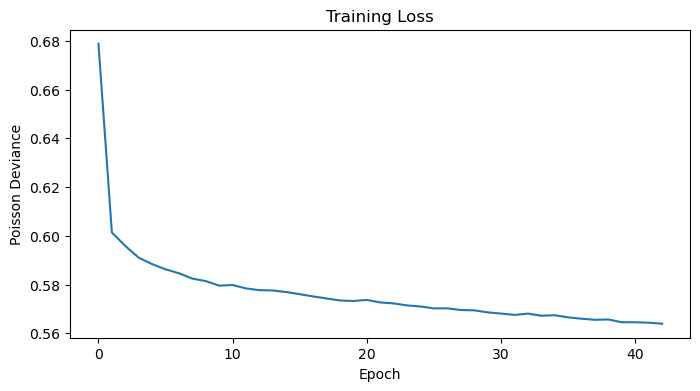

D^2 Calculation
Null Deviance (Baseline): 0.63304
Model Deviance:           0.58458
D^2 Score:                7.65%
-----------------------
Gini Calculation
AUC: 0.33797
Gini :0.32406
---------------


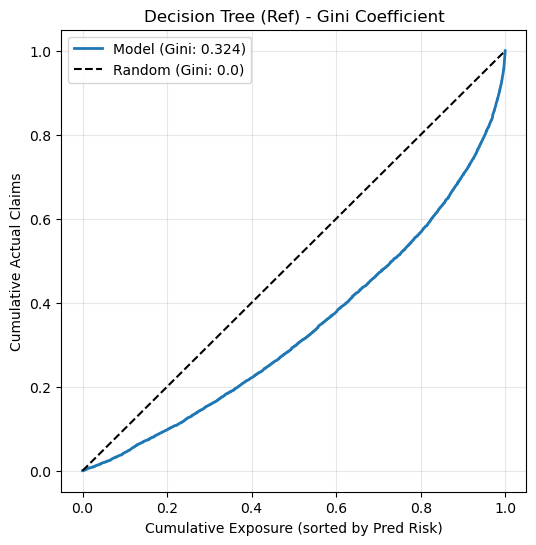

C:\Users\Emil\AppData\Local\Temp\ipykernel_3008\3944565417.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = data.groupby('Bin', observed=False).apply(



---Calibration Plot Data ---
                        AvgPred  AvgTrue    Diff  Exposure
Bin                                                       
(-0.000999424, 0.0476]   0.0370   0.0455 -0.0085 8173.6230
(0.0476, 0.0586]         0.0533   0.0538 -0.0005 7809.9507
(0.0586, 0.0676]         0.0632   0.0638 -0.0007 7675.4541
(0.0676, 0.0764]         0.0720   0.0682  0.0039 7776.8184
(0.0764, 0.0858]         0.0810   0.0788  0.0023 7755.5459
(0.0858, 0.097]          0.0912   0.0903  0.0009 7631.0610
(0.097, 0.112]           0.1040   0.0944  0.0097 7354.4170
(0.112, 0.138]           0.1236   0.1182  0.0054 6648.1982
(0.138, 0.195]           0.1621   0.1562  0.0059 5909.1177
(0.195, 2.783]           0.3539   0.3624 -0.0085 4892.6787
------------------------------------------------



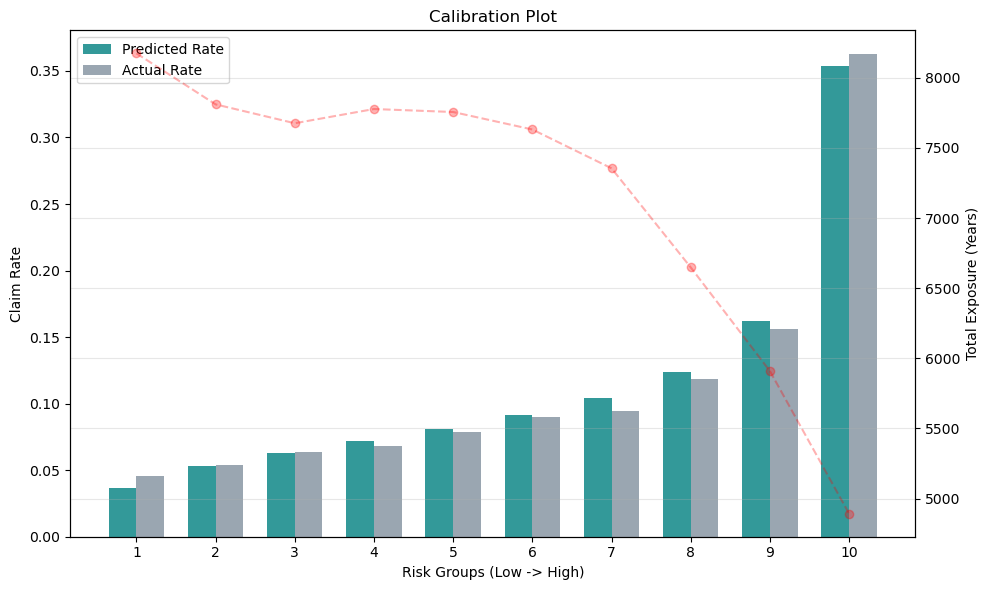

In [7]:
final_lr = best_params['lr']
final_reg = best_params['reg']

print(f"\nTraining Final Model ({best_arch}) with Early Stopping...")


model = DynamicNN(X_train.shape[1], best_arch, dropout_rate=0.2)
optimizer = optim.AdamW(model.parameters(), lr=final_lr, weight_decay=final_reg)


best_val_loss = float('inf')
best_model_state = None
patience = 15
counter = 0
final_epochs = 500
loss_history = []

for epoch in range(final_epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    epoch_num = 0.0
    epoch_den = 0.0
    
    for i in range(0, X_train.size(0), 1024):   
        indices = permutation[i:i+1024]
        batch_x = X_train[indices]
        batch_y = y_train[indices]
        batch_w = w_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = mean_weighted_poisson_deviance_loss(outputs, batch_y, batch_w)
        loss.backward()
        optimizer.step()
        
        
        batch_pred = outputs.detach()
        batch_true = batch_y
        batch_w    = batch_w

        eps = 1e-10
        batch_pred = torch.clamp(batch_pred, min=eps)

        term1 = torch.zeros_like(batch_true)
        mask = batch_true > 0
        term1[mask] = batch_true[mask] * torch.log(batch_true[mask] / batch_pred[mask])

        dev_i = 2.0 * (term1 - (batch_true - batch_pred))  
        epoch_num += torch.sum(batch_w * dev_i).item()
        epoch_den += torch.sum(batch_w).item()
        

    avg_loss = epoch_num / (epoch_den + 1e-12)
    loss_history.append(avg_loss)

    
 
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = mean_weighted_poisson_deviance_loss(val_pred, y_val, w_val).item()
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Val Loss {val_loss:.5f}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Best model weights restored.")


model.eval()
with torch.no_grad():
    y_pred_test = model(X_test).detach().cpu().numpy().ravel()

y_true_test  = y_test.ravel()
w_test_numpy = w_test.ravel()


plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Poisson Deviance")
plt.show()


# Metrics
test_deviance = mean_poisson_deviance(y_true_test, y_pred_test, sample_weight=w_test_numpy )
d2 = d_squared_poisson(y_true_test, y_pred_test, w_test_numpy )

# Gini Plot
plot_lorenz_curve(y_true_test, y_pred_test, w_test_numpy , title="Decision Tree (Ref) - Gini Coefficient")

#Calibration Plot
plot_calibration(y_true_test, y_pred_test, w_test_numpy , n_bins=10)

# Feature Importance
# feature_names = list(X_tr.columns) 
# plot_feature_importance(final_model, feature_names)

In [8]:
from sklearn.metrics import mean_poisson_deviance

model.eval()
with torch.no_grad():
    # Predictions
    y_pred_val  = model(X_val).detach().cpu().numpy().ravel()
    y_pred_test = model(X_test).detach().cpu().numpy().ravel()

# True + weights
y_true_val = y_val.detach().cpu().numpy().ravel()
w_val_np   = w_val.detach().cpu().numpy().ravel()

y_true_test = y_test.detach().cpu().numpy().ravel()
w_test_np   = w_test.detach().cpu().numpy().ravel()

# Deviances (project metric)
val_dev  = mean_poisson_deviance(y_true_val,  y_pred_val,  sample_weight=w_val_np)
test_dev = mean_poisson_deviance(y_true_test, y_pred_test, sample_weight=w_test_np)

print("\n=== PERFORMANCE (PROJECT METRIC) ===")
print(f"Val  Mean Poisson Deviance: {val_dev:.5f}")
print(f"Test Mean Poisson Deviance: {test_dev:.5f}")



=== PERFORMANCE (PROJECT METRIC) ===
Val  Mean Poisson Deviance: 0.58785
Test Mean Poisson Deviance: 0.58458
